# Bull vs Bear Debate

**Docker image**: `ml4t`

A panel that disagrees is more useful than a panel that agrees, and averaging it throws the
disagreement away. **Adversarial debate** is one way to spend it instead: assign one model
the strongest case for yes and another the strongest case for no, show each the other's
argument, and watch what happens to the distance between them over a few rounds.

The distance is the whole output. If it closes, each side had evidence the other had not
weighed and the debate produced something the average could not. If it stays open, both sides
read the same evidence and reached opposite conclusions, and the midpoint reports how wide
the disagreement is rather than a sharper forecast. Those two cases look identical in a single
blended number, which is why this notebook draws the trajectory before it computes one.

**Learning Objectives**:
- Run a multi-round debate in which each side argues against the other's previous position
- Stop the debate when the two sides come within a stated distance of each other, rather than
  after a fixed number of rounds
- Read the gap trajectory to tell a debate that moved something from one that did not
- Fold a debate midpoint back into an aggregate under a stated weight, and say what that
  weight is a claim about
- Decide whether a debate was worth running, from the panel's disagreement and the gap, not
  from the movement of a blend that moves by construction

**Book Reference**: Chapter 24, Section 24.7 (Multi-Agent Forecasting Systems -
Debate Pattern)

**Prerequisites**: [`04_research_agent`](04_research_agent.ipynb) (the agent),
[`05_aggregation_math`](05_aggregation_math.ipynb) (aggregation),
[`06_multi_agent_research`](06_multi_agent_research.ipynb) (running a panel).

**The question, and why it is not the one used in 06.** This notebook forecasts
`CHAPTER_CONTESTED_QUESTION`, *"Will the Federal Reserve hike rates in 2026?"*, where credible
evidence points both ways and the research agents consequently spread out.
[`06_multi_agent_research`](06_multi_agent_research.ipynb) used `CHAPTER_CLEAR_QUESTION`, where
the evidence points one way and the agents landed close together. The agents are identical
across the two notebooks; the question is what differs, and a panel that agrees gives debate
nothing to work on.

As in 06, the numbers are one live `claude-sonnet-4` capture from 2026-06-09, replayed by
default so the table, transcript and figure are the same on every machine. `RUN_LIVE = True`
with `ANTHROPIC_API_KEY` and `TAVILY_API_KEY` debates a current question instead and will not
reproduce these values.

In [1]:
"""Bull vs Bear Debate - adversarial stress-testing of forecasts."""

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import polars as pl
from agent_fixtures import get_chapter_contested_question
from agent_observability import (
    TRACES_DIR,
    RunTrace,
    merge_calls,
    replay_llm_calls,
    show_agents,
    show_debate_transcript,
    trace_llm,
)
from agent_pipeline import neyman_extremize
from agent_providers import ChatMessage, TokenUsage, create_llm_client
from agent_research import ResearchAgent, format_agent_summary, parse_json
from agent_schemas import AgentForecastArtifact, DebateArtifact, DebateRound
from agent_tools import create_search_client

from utils.style import COLORS, add_message_title

## Settings

`RUN_LIVE` left at `False` replays the pinned capture named below and makes no API calls.

`DEBATE_ROUNDS` caps the argument. Three is enough for each side to state a case, answer the
other, and revise; past that the same points tend to be restated at increasing cost.

`CONSENSUS_THRESHOLD` is how close the two sides have to come before the debate stops early.
Five percentage points is inside the resolution anyone should claim for a probability from
this kind of evidence, so continuing past it argues about noise.

`DEBATE_WEIGHT` is how much of the final forecast comes from the debate midpoint rather than
the research agents' aggregate. It is low because the aggregate rests on three independent
evidence-gathering runs while the midpoint rests on two prompts arguing from summaries of
them. Nothing fits this value; it is a stated convention.

`MIN_PANEL_DISAGREEMENT` is the spread below which the panel has effectively agreed and there
is nothing to debate. `MIN_GAP_CLOSURE` is how far the bull-bear gap has to close before the
debate counts as having moved anything.

`NEYMAN_CORRELATION` is the pairwise correlation assumed when the research panel is
aggregated, as in [`05_aggregation_math`](05_aggregation_math.ipynb).

`LLM_PROVIDER` is empty so the factory picks the first provider whose key is set; the capture
used `claude-sonnet-4`, and `"mock"` is a smoke test rather than a reproduction.

In [2]:
RUN_LIVE = False
PINNED_TRACE = "07_adversarial_debate_20260609T141631Z_cf1ad76cf379.json"
LLM_PROVIDER = ""
N_AGENTS = 3
MAX_STEPS = 5
DEBATE_ROUNDS = 3
CONSENSUS_THRESHOLD = 0.05
DEBATE_WEIGHT = 0.3
MIN_PANEL_DISAGREEMENT = 0.05
MIN_GAP_CLOSURE = 0.05
NEYMAN_CORRELATION = 0.3

## Debate Prompts: Bull

The bull argues for a higher probability of YES. In round 1, `{bear_section}`
is empty and the bull argues without seeing the bear's position. In
subsequent rounds, the placeholder carries the bear's previous argument
and the bull must directly address it.

In [3]:
BULL_PROMPT_TEMPLATE = """\
You are the BULL debater in a structured forecasting debate.

Your role is to argue for a HIGHER probability of YES for the question below.
You must present the strongest possible case for YES, backed by evidence.

QUESTION:
{question}

AGENT SUMMARIES:
{agent_summaries}

CURRENT AGGREGATE PROBABILITY: {aggregate_p_yes}

{bear_section}

Output JSON only:
{{"argument": "Your strongest case for a higher probability of YES", "p_yes": 0.XX, "key_evidence": ["evidence point 1", "evidence point 2", "evidence point 3"]}}"""

## Debate Prompts: Bear

The bear argues for a lower probability of YES. The bull's argument and
probability are inserted into the template every round, so the bear is
always responding to the most recent bull position.

In [4]:
BEAR_PROMPT_TEMPLATE = """\
You are the BEAR debater in a structured forecasting debate.

Your role is to argue for a LOWER probability of YES for the question below.
You must present the strongest possible case for NO (or lower probability), backed by evidence.

QUESTION:
{question}

AGENT SUMMARIES:
{agent_summaries}

CURRENT AGGREGATE PROBABILITY: {aggregate_p_yes}

BULL'S ARGUMENT:
{bull_argument}
Bull's probability: {bull_probability}

You must directly address the Bull's points and explain why the probability should be lower.

Output JSON only:
{{"argument": "Your strongest case for a lower probability of YES", "p_yes": 0.XX, "key_evidence": ["evidence point 1", "evidence point 2", "evidence point 3"]}}"""

## One bull turn

The bull sees the common evidence and, after round one, the bear's previous
position. This helper returns the parsed argument, probability, evidence,
and token count.

In [5]:
def _run_bull_turn(
    llm,
    question: str,
    agent_summaries: str,
    aggregate_p_yes: float,
    prev_bear_argument: str | None,
    prev_bear_probability: float | None,
) -> tuple[str, float, list[str], TokenUsage]:
    """Run and parse one bull turn."""
    bear_section = ""
    if prev_bear_argument is not None:
        bear_section = (
            f"BEAR'S PREVIOUS ARGUMENT:\n{prev_bear_argument}\n"
            f"Bear's probability: {prev_bear_probability:.4f}\n\n"
            "You must directly address the Bear's points and explain "
            "why the probability should be higher."
        )

    bull_prompt = BULL_PROMPT_TEMPLATE.format(
        question=question,
        agent_summaries=agent_summaries,
        aggregate_p_yes=f"{aggregate_p_yes:.4f}",
        bear_section=bear_section,
    )
    bull_raw, bull_tokens = llm.complete_with_usage(
        [ChatMessage(role="user", content=bull_prompt)], json_mode=True
    )
    bull_parsed = parse_json(bull_raw)
    return (
        bull_parsed.get("argument", ""),
        float(bull_parsed.get("p_yes", aggregate_p_yes)),
        [str(e) for e in bull_parsed.get("key_evidence", [])],
        bull_tokens,
    )

## One bear turn

The bear always receives the current bull argument. Keeping the two model
calls separate makes the evidence flow and token accounting explicit.

In [6]:
def _run_bear_turn(
    llm,
    question: str,
    agent_summaries: str,
    aggregate_p_yes: float,
    bull_argument: str,
    bull_probability: float,
) -> tuple[str, float, list[str], TokenUsage]:
    """Run and parse one bear turn."""

    bear_prompt = BEAR_PROMPT_TEMPLATE.format(
        question=question,
        agent_summaries=agent_summaries,
        aggregate_p_yes=f"{aggregate_p_yes:.4f}",
        bull_argument=bull_argument,
        bull_probability=f"{bull_probability:.4f}",
    )
    bear_raw, bear_tokens = llm.complete_with_usage(
        [ChatMessage(role="user", content=bear_prompt)], json_mode=True
    )
    bear_parsed = parse_json(bear_raw)
    return (
        bear_parsed.get("argument", ""),
        float(bear_parsed.get("p_yes", aggregate_p_yes)),
        [str(e) for e in bear_parsed.get("key_evidence", [])],
        bear_tokens,
    )

## Single-round driver

One round runs bull then bear and checks whether their probabilities fall
within the declared consensus threshold.

In [7]:
def _run_debate_round(
    llm,
    round_num: int,
    question: str,
    agent_summaries: str,
    aggregate_p_yes: float,
    previous_bear: tuple[str, float] | None,
    consensus_threshold: float,
) -> tuple[DebateRound, TokenUsage]:
    """Run one bull-to-bear round."""
    prev_argument, prev_probability = previous_bear or (None, None)
    bull_argument, bull_p, bull_evidence, bull_tokens = _run_bull_turn(
        llm,
        question,
        agent_summaries,
        aggregate_p_yes,
        prev_argument,
        prev_probability,
    )
    bear_argument, bear_p, bear_evidence, bear_tokens = _run_bear_turn(
        llm, question, agent_summaries, aggregate_p_yes, bull_argument, bull_p
    )

    debate_round = DebateRound(
        round_number=round_num,
        bull_argument=bull_argument,
        bull_probability=bull_p,
        bear_argument=bear_argument,
        bear_probability=bear_p,
        consensus_reached=abs(bull_p - bear_p) < consensus_threshold,
        bull_key_evidence=bull_evidence,
        bear_key_evidence=bear_evidence,
    )
    return debate_round, bull_tokens + bear_tokens

## Multi-round driver

The driver carries the latest bear position into the next bull prompt and
stops once the declared consensus rule fires.

In [8]:
def _conduct_debate(
    llm,
    question: str,
    agent_summaries: str,
    aggregate_p_yes: float,
    max_rounds: int,
    consensus_threshold: float,
) -> tuple[DebateArtifact, TokenUsage]:
    rounds: list[DebateRound] = []
    tokens = TokenUsage()
    previous_bear: tuple[str, float] | None = None
    for round_num in range(1, max_rounds + 1):
        round_result, round_tokens = _run_debate_round(
            llm,
            round_num,
            question,
            agent_summaries,
            aggregate_p_yes,
            previous_bear,
            consensus_threshold,
        )
        rounds.append(round_result)
        tokens = tokens + round_tokens
        if round_result.consensus_reached:
            break
        previous_bear = (round_result.bear_argument, round_result.bear_probability)
    last = rounds[-1]
    return (
        DebateArtifact(
            rounds=rounds,
            bull_final_probability=last.bull_probability,
            bear_final_probability=last.bear_probability,
            consensus_reached=last.consensus_reached,
            early_termination=last.consensus_reached and len(rounds) < max_rounds,
            token_usage=tokens,
        ),
        tokens,
    )

## The DebateAgent Class

Multi-round bull/bear debate. The class owns the LLM, the round budget,
and the consensus threshold; `run()` walks the rounds via the driver
above and assembles a `DebateArtifact` with the full transcript.

In [9]:
class DebateAgent:
    """Structured adversarial debate between bull and bear positions."""

    def __init__(
        self,
        llm,
        max_rounds: int = 3,
        consensus_threshold: float = 0.05,
    ) -> None:
        self.llm = llm
        self.max_rounds = max_rounds
        self.consensus_threshold = consensus_threshold
        self.token_usage = TokenUsage()

    def run(
        self,
        question: str,
        agent_summaries: str,
        aggregate_p_yes: float,
    ) -> DebateArtifact:
        """Run the debate. Returns a DebateArtifact with full transcript."""
        artifact, self.token_usage = _conduct_debate(
            self.llm,
            question,
            agent_summaries,
            aggregate_p_yes,
            self.max_rounds,
            self.consensus_threshold,
        )
        return artifact

## Setup: Run Research Agents

We first run the research agents from [`06_multi_agent_research`](06_multi_agent_research.ipynb) to establish baseline probability
estimates that the debate will stress-test — this time on the pinned contested
question, where the agents are expected to disagree.

In [10]:
artifacts: list[AgentForecastArtifact] = []

if RUN_LIVE:
    llm = create_llm_client(LLM_PROVIDER)
    search = create_search_client(LLM_PROVIDER)
    question = get_chapter_contested_question()
    provider_name = llm.model_name

    # Run N agents, each under its own tracer so the full conversation — every
    # prompt sent and every raw response — is captured and attributed per agent.
    agent_tracers = []
    for i in range(N_AGENTS):
        tracer = trace_llm(llm, label=f"agent_{i}")
        agent = ResearchAgent(llm=tracer, search=search, agent_id=f"agent_{i}", max_steps=MAX_STEPS)
        artifacts.append(agent.run(question, market_price=question.current_market_price))
        agent_tracers.append(tracer)
else:
    # Replay: reload the pinned trace and rehydrate the agent panel and debate.
    pinned_run = RunTrace.load(TRACES_DIR / PINNED_TRACE)
    question = pinned_run.question_obj()
    provider_name = pinned_run.provider
    artifacts = pinned_run.agent_artifacts()

artifacts.sort(key=lambda a: a.agent_id)
answered = [a for a in artifacts if a.forecast_produced]
if not answered:
    raise RuntimeError("no research agent produced a forecast; there is nothing to debate")
panel_probabilities = [a.p_yes for a in answered]
aggregate = neyman_extremize(panel_probabilities, base=0.5, correlation=NEYMAN_CORRELATION)

print(f"Mode:         {'LIVE' if RUN_LIVE else 'REPLAY (pinned 2026-06-09 trace)'}")
print(f"Provider:     {provider_name}")
print(f"Question:     {question.question}")
print(f"Market p_yes: {question.current_market_price}\n")
print("Pre-debate agent estimates:")
for a in answered:
    print(f"  {a.agent_id}: p_yes={a.p_yes:.2f}, confidence={a.confidence:.2f}")
print(f"\nAggregate: {aggregate.extremized_probability:.2f}")

Mode:         REPLAY (pinned 2026-06-09 trace)
Provider:     claude-sonnet-4-20250514
Question:     Will the Federal Reserve hike rates in 2026?
Market p_yes: 0.545

Pre-debate agent estimates:
  agent_0: p_yes=0.35, confidence=0.30
  agent_1: p_yes=0.58, confidence=0.16
  agent_2: p_yes=0.38, confidence=0.24

Aggregate: 0.41


### Where the agents started

Before any argument, here is each research agent's full captured run: every query, the
documents it retrieved, and its untruncated rationale, rendered by the same `show_agents`
helper used in [`06_multi_agent_research`](06_multi_agent_research.ipynb). The agents enter
this debate already disagreeing, and the timelines say which evidence pulled each one where.

In [11]:
print(show_agents(artifacts))

  AGENT_0  ·  p_yes=0.35  confidence=0.30  sentiment=bearish  evidence=high
  searches=3  sources=15  tokens=25,139
  Step 1 · SEARCH  "Federal Reserve interest rate projections 2025 2026 economic outlook inflation"
      1. [?] [PDF] The U.S. Economic Outlook for 2025–2026 - University of Michigan
         https://lsa.umich.edu/content/dam/econ-assets/Econdocs/RSQE%20PDFs/RSQE_US_Forecast_Feb25.pdf
         We project PCE inflation to hold steady near a 2.2 percent annualized
         rate from 2025Q4–2026Q4 .Even so, we expect two more 25 basis point
         cuts in 2026, bringing the fed funds rate to 3.25–3.5 percent by the
         end of 2026, the terminal range for this cycle. It is increasingly
         likely…
      2. [?] Federal Reserve Monetary Policy | U.S. Bank
         https://www.usbank.com/investing/financial-perspectives/market-news/federal-reserve-tapering-asset-purchases.html
         [](https://twitter.com/intent/tweet?url=https://www.usbank.com/conten
         t/

## Running the Debate

The `DebateAgent` makes real LLM calls for each round. The bull and bear
prompts include the agent summaries so both sides argue from the same
evidence base.

In [12]:
agg_p = aggregate.extremized_probability or aggregate.raw_probability

if RUN_LIVE:
    agent_summaries = "\n\n---\n\n".join(format_agent_summary(a) for a in artifacts)
    debate_tracer = trace_llm(llm, label="debate")
    debate = DebateAgent(
        llm=debate_tracer,
        max_rounds=DEBATE_ROUNDS,
        consensus_threshold=CONSENSUS_THRESHOLD,
    )
    result = debate.run(
        question=question.question,
        agent_summaries=agent_summaries,
        aggregate_p_yes=agg_p,
    )
    debate_tokens = debate.token_usage.total_tokens
else:
    # Replay: the saved debate transcript drives every cell below.
    result = pinned_run.debate_obj()
    debate_tokens = result.token_usage.total_tokens

print(f"Debate completed: {len(result.rounds)} rounds")
print(f"Consensus reached: {result.consensus_reached}")
print(f"Bull final: {result.bull_final_probability:.2f}")
print(f"Bear final: {result.bear_final_probability:.2f}")
print(f"Debate tokens: {debate_tokens:,}")

Debate completed: 3 rounds
Consensus reached: False
Bull final: 0.68
Bear final: 0.28
Debate tokens: 6,443


## Round-by-Round Analysis

In [13]:
rounds_df = pl.DataFrame(
    [
        {
            "round": r.round_number,
            "bull": round(r.bull_probability, 3),
            "bear": round(r.bear_probability, 3),
            "gap": round(abs(r.bull_probability - r.bear_probability), 3),
            "consensus": r.consensus_reached,
        }
        for r in result.rounds
    ]
)
rounds_df

round,bull,bear,gap,consensus
i64,f64,f64,f64,bool
1,0.65,0.25,0.4,false
2,0.65,0.28,0.37,false
3,0.68,0.28,0.4,false


The table above is the *shape* of the debate; the transcript below is its
*substance*. `show_debate_transcript` prints each round in full — both sides'
complete arguments and the key evidence they cited, with nothing truncated —
so the reader can see not just that the gap stayed open but the reasoning each
side used to hold its ground. This is the debate counterpart to the panel's
per-agent timelines: the same auditing discipline applied to the adversarial
stage.

In [14]:
print(show_debate_transcript(result))

  DEBATE  ·  3 round(s)  ·  consensus=no  ·  tokens=6,443

  ── Round 1 ──  bull=0.65  bear=0.25  gap=0.40  consensus=no
  BULL (p=0.65):
    The Federal Reserve will likely hike rates in 2026 due to persistent
    inflationary pressures that remain well above target despite recent cuts.
    With core PCE inflation at 3.2% in March 2026 - significantly above the
    Fed's 2% target - and the economy showing resilience, the Fed will be
    forced to reverse course and tighten policy to prevent inflation from
    becoming entrenched. The December 2025 rate cut to 3.5-3.75% was delivered
    with a notably hawkish 9-3 vote, indicating significant internal
    resistance to further easing. The March 2026 dot plot's projection of only
    one additional cut suggests the Fed is already concerned about going too
    far with accommodation. If inflation fails to moderate or accelerates from
    current levels, the Fed will prioritize its price stability mandate over
    growth concerns, especi

## The Gap Across Rounds

One figure answers the question the whole notebook is about: does adversarial pressure close
the distance between the two sides, or does it leave them where they started? The shaded band
is the disagreement itself, and the dotted line is the aggregate the research agents reached
before either debater said anything.

/tmp/ipykernel_2268013/690511601.py:33: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


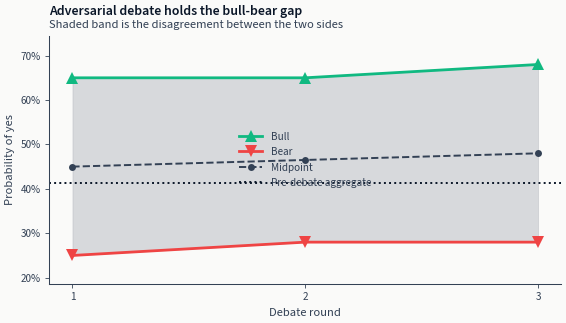

In [15]:
rounds_x = [r.round_number for r in result.rounds]
bull_probs = [r.bull_probability for r in result.rounds]
bear_probs = [r.bear_probability for r in result.rounds]
midpoints = [(b + r) / 2 for b, r in zip(bull_probs, bear_probs, strict=False)]
gaps = [abs(bull - bear) for bull, bear in zip(bull_probs, bear_probs, strict=True)]
change = gaps[-1] - gaps[0]
direction = "narrows" if change < -0.01 else "widens" if change > 0.01 else "holds"

fig, ax = plt.subplots()
ax.plot(
    rounds_x, bull_probs, "^-", color=COLORS["positive"], markersize=8, label="Bull", linewidth=2
)
ax.plot(
    rounds_x, bear_probs, "v-", color=COLORS["negative"], markersize=8, label="Bear", linewidth=2
)
ax.plot(rounds_x, midpoints, "o--", color=COLORS["neutral"], markersize=5, label="Midpoint")
ax.fill_between(rounds_x, bull_probs, bear_probs, alpha=0.15, color=COLORS["blue_light"])
ax.axhline(agg_p, color=COLORS["blue"], linestyle=":", label="Pre-debate aggregate")
ax.set_xlabel("Debate round")
ax.set_ylabel("Probability of yes")
ax.set_xticks(rounds_x)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
add_message_title(
    ax,
    f"Adversarial debate {direction} the bull-bear gap",
    subtitle="Shaded band is the disagreement between the two sides",
)
ax.legend(loc="best")
y_min = min(bear_probs + bull_probs + [agg_p])
y_max = max(bear_probs + bull_probs + [agg_p])
pad = max(0.05, (y_max - y_min) * 0.15)
ax.set_ylim(max(0.0, y_min - pad), min(1.0, y_max + pad))
fig.tight_layout()
plt.show()

A closing gap is the productive case: each side gives ground on the other's strongest point,
and the final midpoint carries a reconciliation that averaging the research agents could not
have produced. A gap that stays the same width means nothing was reconciled, whether or not
both sides moved - they can drift together, which shifts the midpoint while leaving the
disagreement exactly as wide as it was.

So the midpoint on its own says nothing about how much the two sides disagree. A pair of
forecasts far apart and a pair close together have the same midpoint whenever they are
centred on the same point. Disagreement is the gap, which is what the shaded band draws, and
a midpoint reported without it hides how much of the question is unsettled.

## Folding the Debate Back In

The debate produces a midpoint. Turning that into a forecast means deciding how much of it
to believe relative to the aggregate the research agents produced, and there is no fitted
answer to that: `DEBATE_WEIGHT` is a stated convention. It is set low because the aggregate
rests on three independent evidence-gathering runs while the midpoint rests on two prompts
arguing from summaries of them, so the debate adjusts the aggregate rather than replacing it.

A number produced this way is only as good as the debate behind it, which is what the next
section checks before anyone uses it.

In [16]:
pre_debate = agg_p
debate_midpoint = (result.bull_final_probability + result.bear_final_probability) / 2
blended = (1 - DEBATE_WEIGHT) * pre_debate + DEBATE_WEIGHT * debate_midpoint

print(f"Pre-debate aggregate: {pre_debate:.2f}")
print(f"Debate midpoint:      {debate_midpoint:.2f}")
print(f"Blended:              {blended:.2f}")
print(f"Shift from debate:    {blended - pre_debate:+.2f}")

if result.consensus_reached:
    print("\nThe two sides converged within the consensus threshold.")
else:
    print("\nNo consensus: the blended value carries the open disagreement with it.")

Pre-debate aggregate: 0.41
Debate midpoint:      0.48
Blended:              0.43
Shift from debate:    +0.02

No consensus: the blended value carries the open disagreement with it.


## Did the Debate Earn Its Cost?

Two conditions have to hold for the answer to be yes, and they are different questions.

The panel has to have disagreed in the first place: debate applied to three agents already
within a point of each other confirms what was known and bills for it.
`MIN_PANEL_DISAGREEMENT` is the width below which it is not worth starting.

And the debate has to have moved something. The right thing to look at is the gap between
the two sides across rounds, not the shift in the blend: the blend is the pre-debate
aggregate mixed with the midpoint at a fixed weight, so its movement is that weight times
the distance between the midpoint and the aggregate, and it says nothing about whether the
debate itself went anywhere. A gap that closes is the debate working. A gap that holds means
both sides finished where they started, whatever the blend then does to the aggregate.

In [17]:
panel_disagreement = max(panel_probabilities) - min(panel_probabilities)
gap_change = gaps[-1] - gaps[0]
midpoint_move = midpoints[-1] - midpoints[0]
midpoint_move = midpoints[-1] - midpoints[0]

print(f"Panel disagreement before debate:   {panel_disagreement:.2f}")
print(f"Bull-bear gap, first to last round: {gaps[0]:.2f} -> {gaps[-1]:.2f}")
print(f"Midpoint, first to last round:      {midpoints[0]:.2f} -> {midpoints[-1]:.2f}")
print(f"Net midpoint move:                  {midpoint_move:+.2f}")
if panel_disagreement < MIN_PANEL_DISAGREEMENT:
    print("\nThe panel had already agreed; the debate was not worth starting.")
elif gap_change < -MIN_GAP_CLOSURE:
    print(
        "\nDisagreement is narrower at the end than at the start. Whether it narrowed "
        "steadily or moved around on the way is in the per-round table above."
    )
elif gap_change > MIN_GAP_CLOSURE:
    print(
        "\nDisagreement is wider at the end than at the start. The per-round table says "
        "whether it widened throughout or only in the final round."
    )
else:
    print(
        "\nDisagreement ends within the tolerance of where it started, so the debate "
        "reconciled nothing on net. The midpoint line says whether the two sides moved at "
        "all, and the aggregate should be reported with the open gap beside it."
    )

Panel disagreement before debate:   0.23
Bull-bear gap, first to last round: 0.40 -> 0.40
Midpoint, first to last round:      0.45 -> 0.48
Net midpoint move:                  +0.03

Disagreement ends within the tolerance of where it started, so the debate reconciled nothing on net. The midpoint line says whether the two sides moved at all, and the aggregate should be reported with the open gap beside it.


## Persisting the Full Run Trace

The same record as the panel notebook keeps, now covering both stages. `RunTrace`
bundles the question, the research-agent artifacts, the complete debate
transcript, and the raw model conversation for every research and debate call
— captured by the per-agent and debate `TracingLLMClient`s — into one JSON
record under `forecast_traces/`. Reload it to replay exactly what each
debater was shown and how it responded, round by round.

In [18]:
if RUN_LIVE:
    llm_calls = merge_calls(*agent_tracers, debate_tracer)
    run = RunTrace.capture(
        notebook="07_adversarial_debate",
        provider=provider_name,
        question=question,
        params={
            "n_agents": N_AGENTS,
            "debate_rounds": DEBATE_ROUNDS,
            "consensus_threshold": CONSENSUS_THRESHOLD,
            "max_steps": MAX_STEPS,
        },
        agents=artifacts,
        aggregation=aggregate,
        debate=result,
        final_probability=blended,
        notes="Bull/bear debate on the pinned contested question.",
        llm_calls=llm_calls,
    )
    trace_path = run.save()
    print(
        f"Saved {len(run.llm_calls)} model calls "
        f"({run.total_tokens():,} tokens) → {trace_path.relative_to(trace_path.parents[1])}"
    )
else:
    # Replay: report the pinned trace we loaded rather than writing a new file.
    llm_calls = pinned_run.call_log()
    run = pinned_run
    trace_path = TRACES_DIR / PINNED_TRACE
    print(
        f"Replayed {len(run.llm_calls)} model calls "
        f"({run.total_tokens():,} tokens) from {trace_path.name}"
    )

Replayed 20 model calls (93,189 tokens) from 07_adversarial_debate_20260609T141631Z_cf1ad76cf379.json


## Replaying the Debate Calls

The raw audit view for the debate: every bull and bear prompt — including the
opposing side's previous argument that gets fed back in each round — next to
the untruncated JSON each debater returned. The transcript and trajectory
figure above are both derived from exactly these responses.

In [19]:
debate_calls = [c for c in llm_calls if c.label == "debate"]
print(replay_llm_calls(debate_calls, content_chars=700))

  CALL #14 [debate]  ·  claude-sonnet-4-20250514  ·  json_mode=True  ·  tokens in/out=428/330
------------------------------------------------------------------------------
  ▸ USER:
      You are the BULL debater in a structured forecasting debate.
      Your role is to argue for a HIGHER probability of YES for the question
      below.
      You must present the strongest possible case for YES, backed by
      evidence.
      QUESTION:
      Will the Federal Reserve hike rates in 2026?
      AGENT SUMMARIES:
      Agent: agent_0
      Probability (p_yes): 0.35
      Confidence: 0.30
      Rationale: Current evidence strongly suggests rate cuts rather than
      hikes in 2026. The Fed's December 2025 projections forecast only 1 rate
      cut in 2026, bringing rates to 3.25-3.5%. Core PCE inflation is project
      ---
      Agent: agent_1
      Probability (p_yes): 0.58
      Confidence: 0.16
      Rationale: Based on current economic data, the Fed faces persistent
      inflationa…


## Key Takeaways

1. **Debate is a diagnostic before it is an aggregator.** Whether the gap closes tells you
   something the average cannot: closing means the disagreement was informational and one
   side had evidence the other had not weighed; holding means the two sides read the same
   evidence and drew different conclusions from it. Only the first is a case for updating.
2. **A midpoint that does not move is a result.** Blending an unchanged midpoint into the
   aggregate produces a number that looks updated and is not, which is worse than reporting
   the aggregate and the open gap side by side.
3. **Adversarial roles are a prompt, not a mechanism.** Both debaters are the same model told
   to argue opposite sides from the same evidence, so a narrowing gap is two prompts
   converging rather than two analysts persuading each other. It is a cheap stress test and
   not an independent second opinion.
4. **Terminate on the gap, not on the round count.** Once the two sides are within the
   consensus threshold there is nothing left to argue, and every further round is paid for.
5. **Debate only earns its cost where the panel already disagrees.** Running it on a panel
   that agreed spends tokens to confirm the agreement.

**Known limitations of what is built here.** One capture, one question, three rounds: nothing
establishes that the gap would behave this way again. The bull and bear see agent summaries
rather than the underlying evidence, so neither can check a claim the other makes. The blend
weight is a stated convention rather than a fitted parameter, and no scoring anywhere
establishes that a blended forecast scores better than the aggregate it adjusts.

**Next**: [`08_forecasting_pipeline`](08_forecasting_pipeline.ipynb) wires the research,
aggregation, debate and supervisor stages into one runnable pipeline.

**Book**: Section 24.7 discusses the debate pattern in the context of Bridgewater's
AIA system and prediction market design.